In [1]:
# ==========================================================
# Pneumonia Detection using EfficientNetB0
# Import Libraries & Set Random Seed
# ==========================================================

!pip install -q kagglehub

# Standard Libraries
import os
import random
from pathlib import Path

# Data Handling
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt

# Deep Learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Evaluation
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

# Kaggle Dataset Downloader
import kagglehub

# ==========================================================
# Check Versions
# ==========================================================

print("TensorFlow Version:", tf.__version__)
print("NumPy Version:", np.__version__)
print("Pandas Version:", pd.__version__)

# ==========================================================
# Set Random Seed
# ==========================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("\nLibraries imported successfully!")

TensorFlow Version: 2.20.0
NumPy Version: 2.0.2
Pandas Version: 2.2.2

Libraries imported successfully!


In [2]:
# ==========================================================
# Set Dataset Path & Count Images
# ==========================================================

from pathlib import Path
import kagglehub

# Download dataset
dataset_path = Path(kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia"))

# Detect correct dataset path
if (dataset_path / "train").exists():
    DATASET_PATH = dataset_path
else:
    DATASET_PATH = dataset_path / "chest_xray"

print("=" * 50)
print("Dataset Path:", DATASET_PATH)
print("=" * 50)

# Count images in each split
for split in ["train", "test", "val"]:
    split_path = DATASET_PATH / split
    print(f"\n📂 {split.upper()}")

    total = 0
    for cls in ["NORMAL", "PNEUMONIA"]:
        count = len(list((split_path / cls).glob("*")))
        total += count
        print(f"{cls:<12}: {count}")

    print(f"Total Images: {total}")

Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.
Dataset Path: /kaggle/input/chest-xray-pneumonia/chest_xray

📂 TRAIN
NORMAL      : 1341
PNEUMONIA   : 3875
Total Images: 5216

📂 TEST
NORMAL      : 234
PNEUMONIA   : 390
Total Images: 624

📂 VAL
NORMAL      : 8
PNEUMONIA   : 8
Total Images: 16


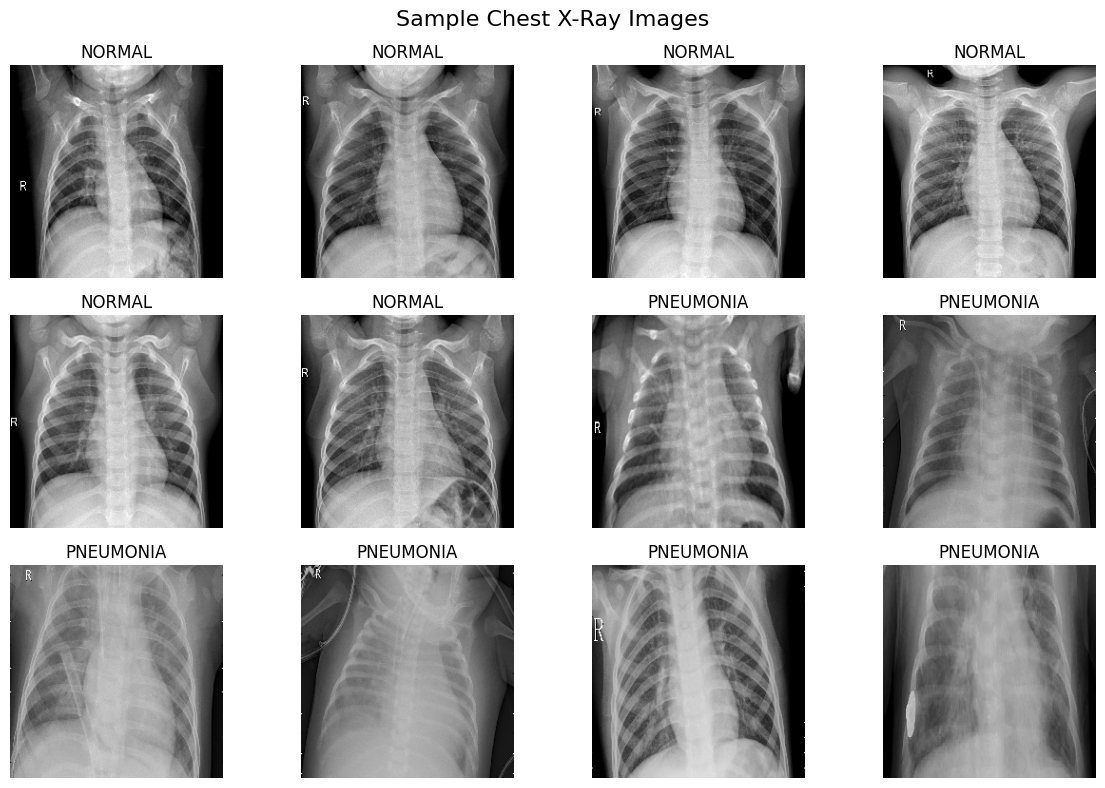

In [3]:
import random
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import load_img

classes = ["NORMAL", "PNEUMONIA"]

plt.figure(figsize=(12, 8))

for i in range(12):
    cls = classes[i // 6]

    image_path = random.choice(list((DATASET_PATH / "train" / cls).glob("*")))

    img = load_img(image_path, target_size=(224, 224))

    plt.subplot(3, 4, i + 1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis("off")

plt.suptitle("Sample Chest X-Ray Images", fontsize=16)
plt.tight_layout()
plt.show()

In [4]:
# ==========================================================
# Check for Corrupted Images
# ==========================================================

from PIL import Image

corrupted_images = []

for split in ["train", "test", "val"]:
    for cls in ["NORMAL", "PNEUMONIA"]:
        folder = DATASET_PATH / split / cls

        for image_path in folder.glob("*"):
            try:
                img = Image.open(image_path)
                img.verify()   # Verify image integrity
            except Exception:
                corrupted_images.append(image_path)

print("=" * 50)
print(f"Total Corrupted Images: {len(corrupted_images)}")

if corrupted_images:
    print("\nCorrupted Images:")
    for img in corrupted_images:
        print(img)
else:
    print("✅ No corrupted images found.")

Total Corrupted Images: 0
✅ No corrupted images found.


In [5]:
# ==========================================================
# Load Dataset
# ==========================================================

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

train_dataset = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH / "train",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
    shuffle=True,
    seed=SEED
)

validation_dataset = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH / "val",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
    shuffle=False
)

test_dataset = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH / "test",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
    shuffle=False
)

class_names = train_dataset.class_names

print("Classes:", class_names)

Found 5216 files belonging to 2 classes.
Found 16 files belonging to 2 classes.
Found 624 files belonging to 2 classes.
Classes: ['NORMAL', 'PNEUMONIA']


In [6]:
# ==========================================================
# Optimize Dataset Performance
# ==========================================================

AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.cache().prefetch(AUTOTUNE)
validation_dataset = validation_dataset.cache().prefetch(AUTOTUNE)
test_dataset = test_dataset.prefetch(AUTOTUNE)

print("Datasets are ready!")

Datasets are ready!


In [7]:
# ==========================================================
# Check Dataset Shape
# ==========================================================

for images, labels in train_dataset.take(1):
    print("Images Shape :", images.shape)
    print("Labels Shape :", labels.shape)

Images Shape : (32, 224, 224, 3)
Labels Shape : (32, 1)


<Sequential name=data_augmentation, built=False>


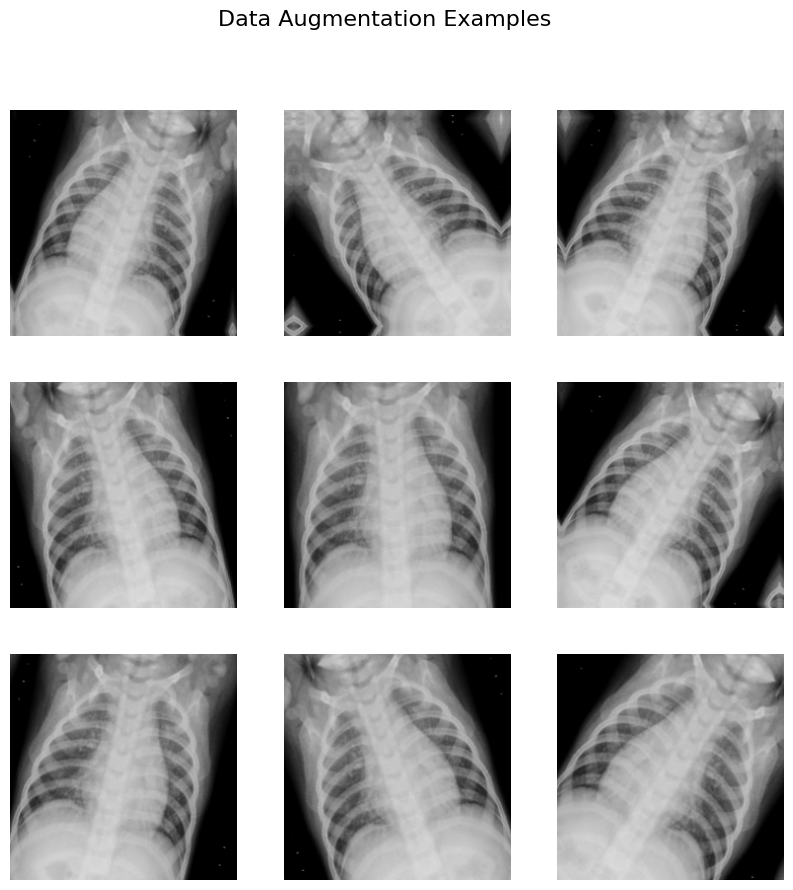

In [8]:
# ==========================================================
# Data Augmentation
# ==========================================================

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
], name="data_augmentation")

print(data_augmentation)

# ==========================================================
# Visualize Data Augmentation
# ==========================================================

plt.figure(figsize=(10, 10))

for images, labels in train_dataset.take(1):
    first_image = images[0]

    for i in range(9):
        augmented_image = data_augmentation(
            tf.expand_dims(first_image, axis=0),
            training=True
        )

        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(augmented_image[0].numpy().astype("uint8"))
        plt.axis("off")

plt.suptitle("Data Augmentation Examples", fontsize=16)
plt.show()

In [9]:
# ==========================================================
# Load Pre-trained EfficientNetB0
# ==========================================================

base_model = tf.keras.applications.EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze the base model
base_model.trainable = False


# ==========================================================
# Build the Model
# ==========================================================

inputs = keras.Input(shape=(224, 224, 3))

# Data Augmentation
x = data_augmentation(inputs)

# EfficientNet preprocessing
x = tf.keras.applications.efficientnet.preprocess_input(x)

# Feature Extraction
x = base_model(x, training=False)

# Classification Head
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.2)(x)
x = layers.Dense(128, activation="relu")(x)
outputs = layers.Dense(1, activation="sigmoid")(x)

model = keras.Model(inputs, outputs)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [10]:
# ==========================================================
# Compile Model
# ==========================================================

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)


# ==========================================================
# Callbacks
# ==========================================================

callbacks = [

    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),

    tf.keras.callbacks.ModelCheckpoint(
        "best_model.keras",
        monitor="val_accuracy",
        save_best_only=True
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=2,
        min_lr=1e-6
    )

]

In [11]:
# ==========================================================
# Train Model
# ==========================================================

EPOCHS = 15

history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=EPOCHS,
    callbacks=callbacks
)

Epoch 1/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 558s 3s/step - accuracy: 0.9036 - loss: 0.2181 - val_accuracy: 0.8750 - val_loss: 0.1980 - learning_rate: 0.0010
Epoch 2/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 495s 3s/step - accuracy: 0.9387 - loss: 0.1534 - val_accuracy: 1.0000 - val_loss: 0.0996 - learning_rate: 0.0010
Epoch 3/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 486s 3s/step - accuracy: 0.9433 - loss: 0.1381 - val_accuracy: 1.0000 - val_loss: 0.0976 - learning_rate: 0.0010
Epoch 4/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 517s 3s/step - accuracy: 0.9421 - loss: 0.1451 - val_accuracy: 0.9375 - val_loss: 0.2176 - learning_rate: 0.0010
Epoch 5/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 491s 3s/step - accuracy: 0.9484 - loss: 0.1306 - val_accuracy: 0.9375 - val_loss: 0.0977 - learning_rate: 0.0010
Epoch 6/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 482s 3s/step - accuracy: 0.9605 - loss: 0.1078 - val_accuracy: 1.0000 - val_loss: 0.1087 - learning_rate: 2.0000e-04
Epoch 7/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 496s 3s/step - accuracy: 0.9519 - loss

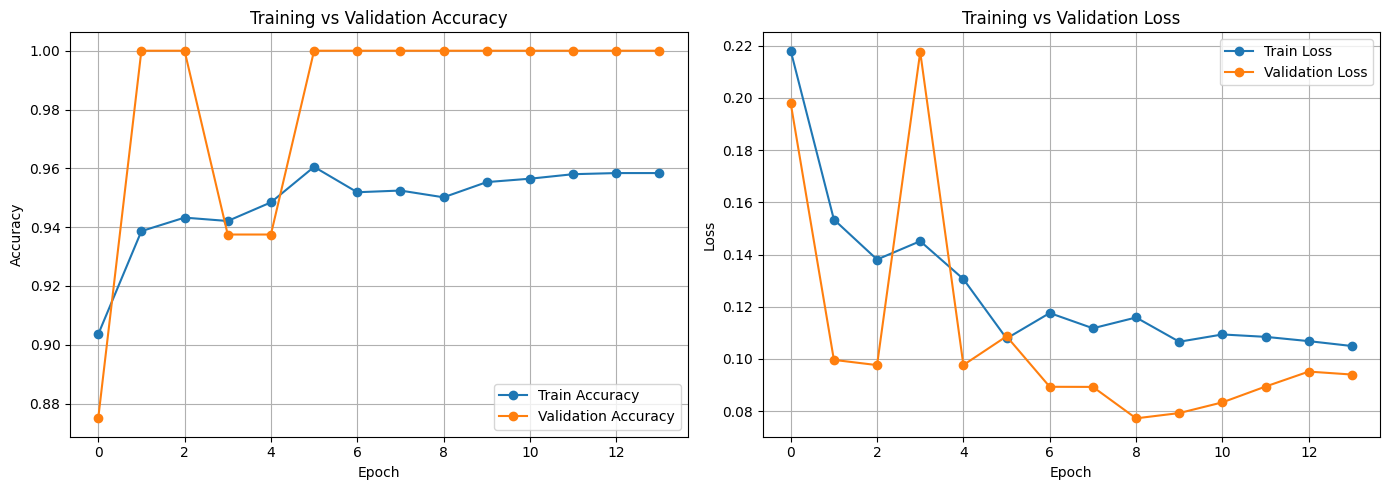

In [50]:
# ==========================================================
# Plot Training & Validation Accuracy and Loss
# ==========================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))

# ---------------- Accuracy ----------------
plt.subplot(1, 2, 1)

plt.plot(history.history["accuracy"], marker="o", label="Train Accuracy")
plt.plot(history.history["val_accuracy"], marker="o", label="Validation Accuracy")

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

# ---------------- Loss ----------------
plt.subplot(1, 2, 2)

plt.plot(history.history["loss"], marker="o", label="Train Loss")
plt.plot(history.history["val_loss"], marker="o", label="Validation Loss")

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [14]:
# ==========================================================
# Predict Test Set
# ==========================================================

import numpy as np

y_true = []
y_pred = []

for images, labels in test_dataset:

    predictions = model.predict(images, verbose=0)

    predictions = (predictions > 0.5).astype(int)

    y_true.extend(labels.numpy().astype(int).flatten())
    y_pred.extend(predictions.flatten())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

In [15]:
# ==========================================================
# Classification Report
# ==========================================================

from sklearn.metrics import classification_report

print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))

              precision    recall  f1-score   support

      NORMAL       0.93      0.75      0.83       234
   PNEUMONIA       0.86      0.97      0.91       390

    accuracy                           0.88       624
   macro avg       0.90      0.86      0.87       624
weighted avg       0.89      0.88      0.88       624



<Figure size 600x600 with 0 Axes>

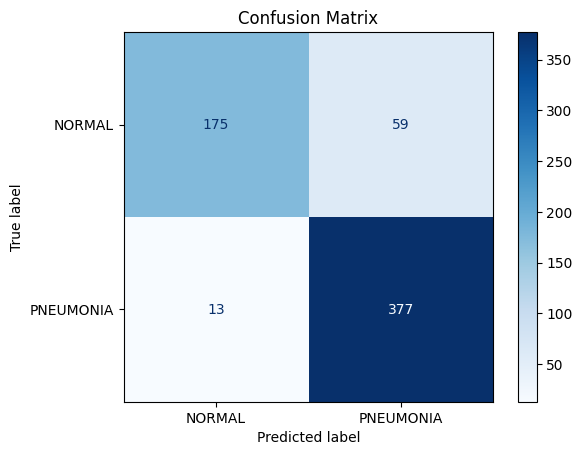

In [16]:
# ==========================================================
# Confusion Matrix
# ==========================================================

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

plt.figure(figsize=(6,6))
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix")
plt.show()

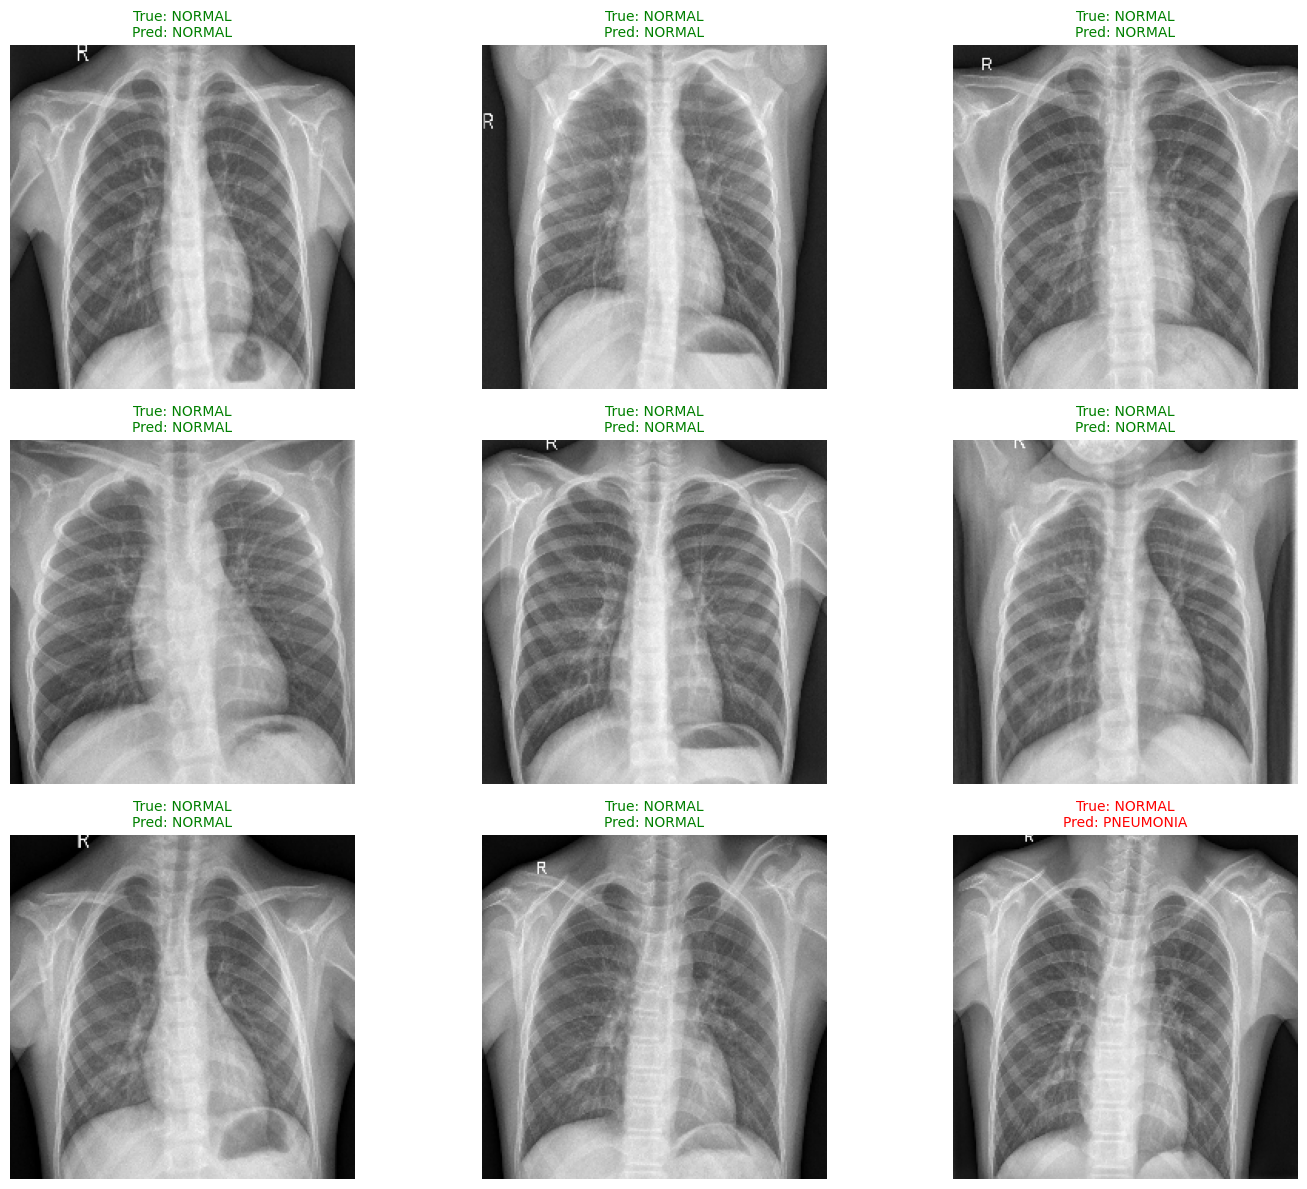

In [45]:
# ==========================================================
# Display Sample Predictions
# ==========================================================

import matplotlib.pyplot as plt
import numpy as np

class_names = ["NORMAL", "PNEUMONIA"]

images, labels = next(iter(test_dataset))

predictions = model.predict(images, verbose=0)
predictions = (predictions > 0.5).astype(int).flatten()

plt.figure(figsize=(15, 12))

for i in range(9):

    plt.subplot(3, 3, i + 1)

    plt.imshow(images[i].numpy().astype("uint8"))

    true_label = class_names[int(labels[i])]
    pred_label = class_names[int(predictions[i])]

    color = "green" if true_label == pred_label else "red"

    plt.title(
        f"True: {true_label}\nPred: {pred_label}",
        color=color,
        fontsize=10
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

In [46]:
# ==========================================================
# Display Wrong Predictions
# ==========================================================

import matplotlib.pyplot as plt
import numpy as np

class_names = ["NORMAL", "PNEUMONIA"]

wrong_images = []
wrong_true = []
wrong_pred = []

for images, labels in test_dataset:

    predictions = model.predict(images, verbose=0)
    predictions = (predictions > 0.5).astype(int).flatten()

    for i in range(len(labels)):

        if predictions[i] != labels[i]:

            wrong_images.append(images[i].numpy().astype("uint8"))
            wrong_true.append(class_names[int(labels[i])])
            wrong_pred.append(class_names[int(predictions[i])])

print(f"Total Wrong Predictions: {len(wrong_images)}")

Total Wrong Predictions: 72


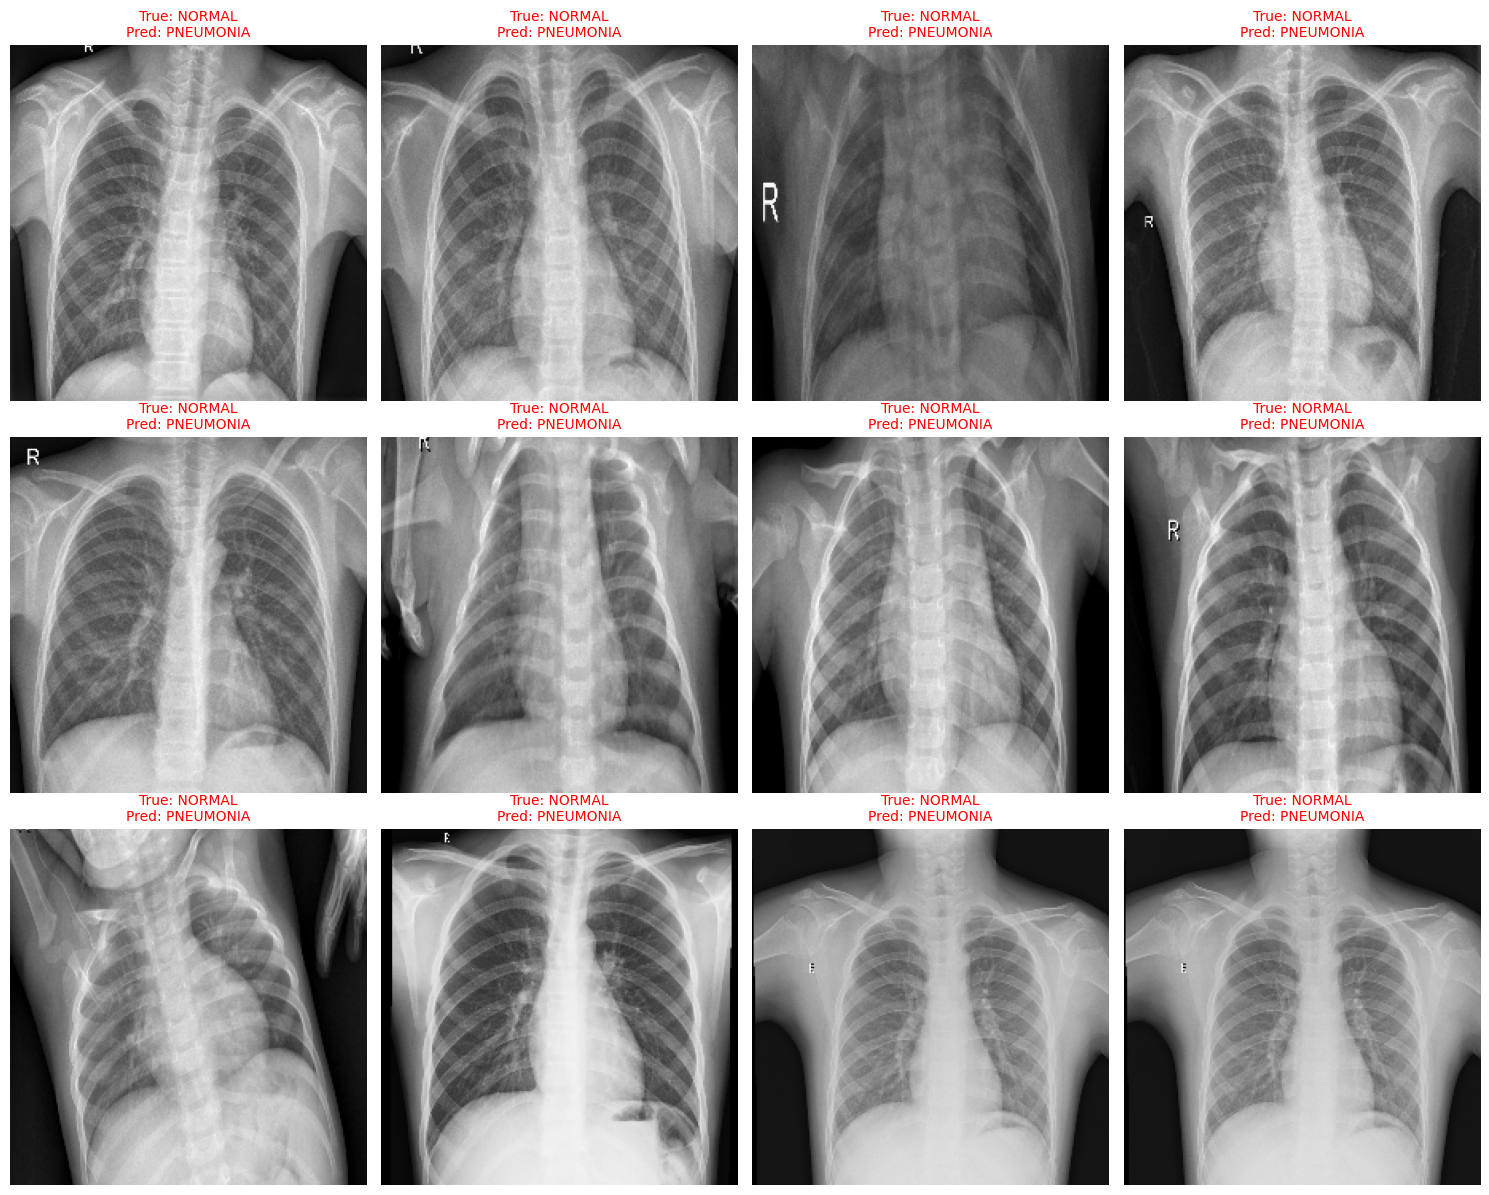

In [47]:
# ==========================================================
# Show Wrong Predictions
# ==========================================================

num_images = min(12, len(wrong_images))

plt.figure(figsize=(15, 12))

for i in range(num_images):

    plt.subplot(3, 4, i + 1)

    plt.imshow(wrong_images[i])

    plt.title(
        f"True: {wrong_true[i]}\nPred: {wrong_pred[i]}",
        color="red",
        fontsize=10
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

Saving custom_image.jfif to custom_image.jfif


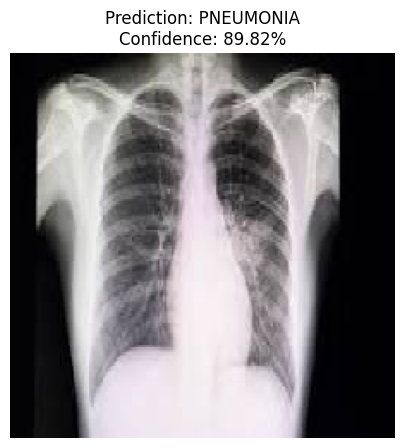

Prediction : PNEUMONIA
Confidence : 89.82%


In [48]:
# ==========================================================
# Upload Custom X-ray Image
# ==========================================================

from google.colab import files

uploaded = files.upload()


# ==========================================================
# Predict Custom Image
# ==========================================================

import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

class_names = ["NORMAL", "PNEUMONIA"]

image_path = list(uploaded.keys())[0]

img = image.load_img(image_path, target_size=(224,224))

img_array = image.img_to_array(img)

img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array, verbose=0)[0][0]

confidence = prediction if prediction >= 0.5 else 1 - prediction

predicted_class = class_names[int(prediction >= 0.5)]

plt.figure(figsize=(5,5))
plt.imshow(img)
plt.axis("off")
plt.title(
    f"Prediction: {predicted_class}\nConfidence: {confidence*100:.2f}%"
)
plt.show()

print("=" * 50)
print(f"Prediction : {predicted_class}")
print(f"Confidence : {confidence*100:.2f}%")
print("=" * 50)

In [49]:
model.save("Pneumonia_Detection_EfficientNetB0.keras")